In [1]:
# for this task i will make the dance and label encoding too close first then use the autoencoder for reconstruction 

In [3]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
np.random.seed(42)
torch.manual_seed(42)

In [7]:
file_path = "../data/mariel_betternot_and_retrograde.npy"  # Replace with your data file
def preprocesss(file_path,seq_len=50):
    dat = np.load(file_path)[:,4000:8000,:] 
    data = dat.transpose(1, 0, 2)  
    point_mask = np.ones(55, dtype=bool)
    point_mask[[26,53]] = False
    data = data[:, point_mask, :]  # Now (timesteps, 53, 3)
    
    # Invert Z-axis (matching original processing)
    data[..., 2] *= -1
    data = data.reshape(data.shape[0]//seq_len, seq_len, 53*3)
    data = torch.tensor(data,dtype=torch.float)
    return data

In [9]:
data=preprocesss(file_path)
data.shape

torch.Size([80, 50, 159])

In [21]:
text = 'swing'
dance = data[0]

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 78.18it/s]


Saved animate/tempppp.gif and animate/tempppp.mp4


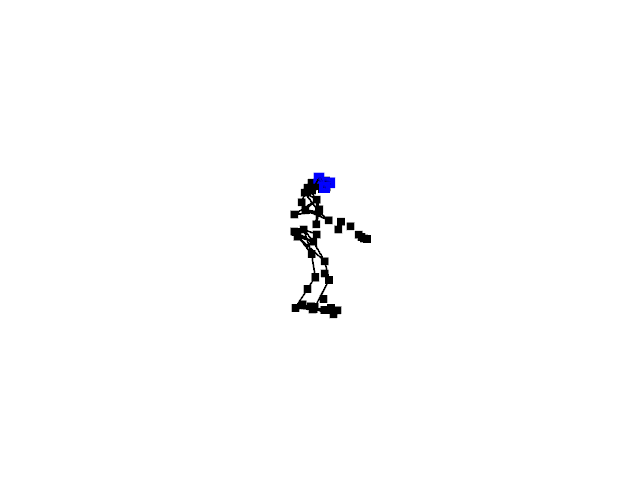

In [23]:
#labels and skeleton connections (from original code)
point_labels = ['ARIEL', 'C7', 'CLAV', 'LANK', 'LBHD', 'LBSH', 'LBWT', 'LELB', 'LFHD', 'LFRM', 
                'LFSH', 'LFWT', 'LHEL', 'LIEL', 'LIHAND', 'LIWR', 'LKNE', 'LKNI', 'LMT1', 'LMT5', 
                'LOHAND', 'LOWR', 'LSHN', 'LTHI', 'LTOE', 'LUPA', 'MBWT', 'MFWT', 'RANK', 'RBHD', 
                'RBSH', 'RBWT', 'RELB', 'RFHD', 'RFRM', 'RFSH', 'RFWT', 'RHEL', 'RIEL', 'RIHAND', 
                'RIWR', 'RKNE', 'RKNI', 'RMT1', 'RMT5', 'ROHAND', 'ROWR', 'RSHN', 'RTHI', 'RTOE', 
                'RUPA', 'STRN', 'T10']
skeleton_lines = [
    (('LHEL',), ('LTOE',)), (('RHEL',), ('RTOE',)), (('LMT1',), ('LMT5',)), (('RMT1',), ('RMT5',)),
    (('LHEL',), ('LMT1',)), (('LHEL',), ('LMT5',)), (('RHEL',), ('RMT1',)), (('RHEL',), ('RMT5',)),
    (('LTOE',), ('LMT1',)), (('LTOE',), ('LMT5',)), (('RTOE',), ('RMT1',)), (('RTOE',), ('RMT5',)),
    (('LKNE',), ('LHEL',)), (('RKNE',), ('RHEL',)), (('LFWT',), ('RBWT',)), (('RFWT',), ('LBWT',)),
    (('LFWT',), ('RFWT',)), (('LBWT',), ('RBWT',)), (('LFWT',), ('LBWT',)), (('RFWT',), ('RBWT',)),
    (('LFWT',), ('LTHI',)), (('RFWT',), ('RTHI',)), (('LBWT',), ('LTHI',)), (('RBWT',), ('RTHI',)),
    (('LKNE',), ('LTHI',)), (('RKNE',), ('RTHI',)), 
    (('CLAV',), ('RFSH',)),
    (('STRN',), ('LFSH',)), (('STRN',), ('RFSH',)), (('T10',), ('LFSH',)), (('T10',), ('RFSH',)),
    (('C7',), ('LBSH',)), (('C7',), ('RBSH',)), (('LFSH',), ('LBSH',)), (('RFSH',), ('RBSH',)),
    (('LFSH',), ('RBSH',)), (('RFSH',), ('LBSH',)), (('LFSH',), ('LUPA',)), (('RFSH',), ('RUPA',)),
    (('LBSH',), ('LUPA',)), (('RBSH',), ('RUPA',)), (('LIWR',), ('LIHAND',)), (('RIWR',), ('RIHAND',)),
    (('LOWR',), ('LOHAND',)), (('ROWR',), ('ROHAND',)), (('LIWR',), ('LOWR',)), (('RIWR',), ('ROWR',)),
    (('LIHAND',), ('LOHAND',)), (('RIHAND',), ('ROHAND',)), (('LFHD',), ('LBHD',)), (('LBHD',), ('RBHD',)),
    (('RBHD',), ('RFHD',)), (('RFHD',), ('LFHD',)), (('LFHD',), ('ARIEL',)), (('LBHD',), ('ARIEL',)),
    (('RBHD',), ('ARIEL',)), 
    (('RFHD',), ('ARIEL',)),
    (('RFWT',), ('MFWT',)),(('LFWT',), ('MFWT',)),(('LFSH',), ('RFSH',)) # added 
]
# from pirounet paper simpler representation
skeleton_lines2 = [
    #     ( (start group), (end group) ),
    (("LHEL",), ("LTOE",)),  # toe to heel
    (("RHEL",), ("RTOE",)),
    (("LKNE", "LKNI"), ("LHEL",)),  # heel to knee
    (("RKNE", "RKNI"), ("RHEL",)),
    (("LKNE", "LKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),  # knee to "navel"
    (("RKNE", "RKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),
    (
        ("LFWT", "RFWT", "LBWT", "RBWT"),
        (
            "STRN",
            "T10",
        ),
    ),  # "navel" to chest
    (
        (
            "STRN",
            "T10",
        ),
        (
            "CLAV",
            "C7",
        ),
    ),  # chest to neck
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "LFSH",
            "LBSH",
        ),
    ),  # neck to shoulders
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "RFSH",
            "RBSH",
        ),
    ),
    (
        (
            "LFSH",
            "LBSH",
        ),
        (
            "LELB",
            "LIEL",
        ),
    ),  # shoulders to elbows
    (
        (
            "RFSH",
            "RBSH",
        ),
        (
            "RELB",
            "RIEL",
        ),
    ),
    (
        (
            "LELB",
            "LIEL",
        ),
        (
            "LOWR",
            "LIWR",
        ),
    ),  # elbows to wrist
    (
        (
            "RELB",
            "RIEL",
        ),
        (
            "ROWR",
            "RIWR",
        ),
    ),
    (("LFHD",), ("LBHD",)),  # draw lines around circumference of the head
    (("LBHD",), ("RBHD",)),
    (("RBHD",), ("RFHD",)),
    (("RFHD",), ("LFHD",)),
    (("LFHD",), ("ARIEL",)),  # connect circumference points to top of head
    (("LBHD",), ("ARIEL",)),
    (("RBHD",), ("ARIEL",)),
    (("RFHD",), ("ARIEL",)),
]

reduced_joint_names = [
    'ARIEL', 'C7', 'CLAV', 'STRN',  # Head & Spine
    'RFSH', 'LFSH', 'RBSH', 'LBSH',  # Shoulders
    'RIEL', 'LIEL', 'RIWR', 'LIWR',  # Elbows & Wrists
    'RKNE', 'LKNE', 'RTOE', 'LTOE',  # Knees & Toes
    'RHEL', 'LHEL',  # Heels
    'RFWT', 'LFWT', 'RBWT', 'LBWT',  # Hip/Pelvis
    'RTHI', 'LTHI', 'RSHN', 'LSHN'  # Thighs & Shins
]
def create_skeleton(points, labels, connections, show_points=True, reduced_joint_names=None):
    label_to_idx = {label: i for i, label in enumerate(labels)}
    valid_indices = (np.arange(len(labels)) if reduced_joint_names is None 
                     else np.array([label_to_idx[j] for j in reduced_joint_names if j in label_to_idx]))
    if len(valid_indices) < 2:
        raise ValueError("At least two valid joints are needed.")
    
    index_map = {old: new for new, old in enumerate(valid_indices)}
    
    lines = np.hstack([[2, index_map[s], index_map[e]] 
                      for a, b in connections 
                      if (s := label_to_idx.get(a[0])) in index_map 
                      and (e := label_to_idx.get(b[0])) in index_map]).astype(np.int32)
    
    mesh = pv.PolyData(np.asarray(points)[valid_indices])
    if lines.size > 0:
        mesh.lines = lines
    
    return mesh, 10 if show_points else 0
def create_skeleton2(points, show_points=True): #for face triangle colour
    points = np.array(points)
    if points.shape[1] != 3 or len(points) < 2:
        raise ValueError("Points must have shape (N,3) with at least two points.")
    lines = np.array([(2, i, i + 1) for i in range(len(points) - 1)], dtype=np.int32).flatten()
    if len(points) == 3:
        lines = np.append(lines, [2, 2, 0])

    mesh = pv.PolyData(points)
    if lines.size > 0:
        mesh.lines = lines

    return mesh, 10 if show_points else 0
import os
import numpy as np
import cv2
import pyvista as pv
import imageio.v2 as iio
from tqdm import tqdm

def generate_skeleton_animation(data, output_name="skeleton_animation", stride=1, fps=24):
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  

    label_to_idx = {label: idx for idx, label in enumerate(point_labels)}
    head_indices = np.array([0, 8, 33])  

    all_points = data.reshape(-1, data.shape[-1])
    global_min = all_points.min(axis=0)
    global_max = all_points.max(axis=0)
    global_center = (global_min + global_max) / 2
    global_diagonal = np.linalg.norm(global_max - global_min)
    global_view_distance = global_diagonal * 1.5

    camera_position = [
        global_center[0] + global_view_distance * 0.5,
        global_center[1] + global_view_distance * 0.3,
        global_center[2] + global_view_distance * 0.4
    ]

    plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
    plotter.reset_camera()
    plotter.camera.zoom(2.0) 
    prev_frame = data[0]
    start_saving = False  
    movement_threshold = 0.001 * global_diagonal  
    total_frames = min(data.shape[0], 1500)  

    output_gif = f"{output_name}.gif"
    output_mp4 = f"{output_name}.mp4"

    with iio.get_writer(output_gif, mode="I", duration=int(1000 / fps)) as gif_writer:
        video_writer = None

        for t in tqdm(range(0, total_frames, stride)):
            current_frame = data[t]
            movement = np.linalg.norm(current_frame - prev_frame)

            if movement > movement_threshold or t > 0:
                start_saving = True 

            if start_saving:
                frame_center = current_frame.mean(axis=0)
                camera_position = [
                    frame_center[0] + global_view_distance * 0.5,
                    frame_center[1] + global_view_distance * 0.3,
                    frame_center[2] + global_view_distance * 0.4
                ]
                plotter.camera_position = [camera_position, frame_center, [0, 0, 1]]

                mesh, point_size = create_skeleton(current_frame, point_labels, skeleton_lines, show_points=True)
                mesh2, point_size2 = create_skeleton2(current_frame[head_indices], show_points=True)
                # point_size=0
                # point_size2=0
                plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, point_size=point_size/1.25 , color='black')
                plotter.add_mesh(mesh2, render_lines_as_tubes=True, line_width=3, point_size=point_size2 * 1.1, color='red')

                img = plotter.screenshot(return_img=True)
                frame = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)

                gif_writer.append_data(frame)

                if video_writer is None:
                    height, width, _ = frame.shape
                    video_writer = cv2.VideoWriter(output_mp4, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

                video_writer.write(frame)
                plotter.clear_actors()

            prev_frame = current_frame  

            if t % 100 == 0:
                plotter.close()
                del plotter
                plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  
                plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
                plotter.camera.zoom(0.50) 

        if video_writer:
            video_writer.release()

    plotter.close()
    del plotter  

    print(f"Saved {output_gif} and {output_mp4}")
def visualize(one_seq,filename='tempppp'):
    path = os.path.join("animate", f"{filename}")
    inp = np.array(one_seq.detach().reshape(one_seq.shape[0],53,3))
    # print(inp.shape)
    generate_skeleton_animation(inp,output_name=path)
visualize(data[0])
from IPython.display import Image
Image(filename='animate/tempppp.gif')

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class MotionAutoencoder(nn.Module):
    def __init__(self, seq_len=40, input_dim=159, latent_dim=64):
        super(MotionAutoencoder, self).__init__()
        
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(seq_len * input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, seq_len * input_dim)
        )
    
    def forward(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        
        z = self.encoder(x)
        reconstruction = self.decoder(z)
        reconstruction = reconstruction.reshape(batch_size, self.seq_len, self.input_dim)
        
        return reconstruction, z
    
    def encode(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        return self.encoder(x)
    
    def decode(self, z):
        batch_size = z.shape[0]
        reconstruction = self.decoder(z)
        return reconstruction.reshape(batch_size, self.seq_len, self.input_dim)

In [188]:
model = MotionAutoencoder(seq_len=50, input_dim=159, latent_dim=64)
model.load_state_dict(torch.load('best_autoencoder.pth'))
print("Best model loaded.")

Best model loaded.


100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 35.93it/s]


Saved animate/reconstructed.gif and animate/reconstructed.mp4


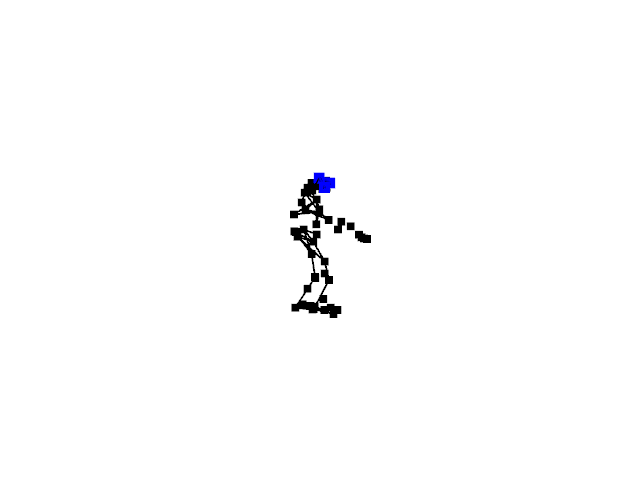

In [190]:
rec = model.decode(model.encode(data[:1])).squeeze(0)
visualize(rec,filename='reconstructed')
Image(filename='animate/reconstructed.gif')

In [191]:
encoded = model.encode(data[:1])
encoded.shape

torch.Size([1, 64])

In [580]:
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import BertModel, BertTokenizer

class TextMapper(nn.Module):
    def __init__(self, text_embedding_dim=768, latent_dim=64, dropout_rate=0.0):
        super(TextMapper, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(text_embedding_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, latent_dim),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        return self.model(x)

# Load pretrained BERT model & tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
bert_model = BertModel.from_pretrained("bert-base-uncased")

def get_bert_embedding(text):
    tokens = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=50)
    with torch.no_grad():
        output = bert_model(**tokens)
    return output.last_hidden_state[:, 0, :]  # CLS token representation

motion_autoencoder = model 
motion_autoencoder.eval()
for param in motion_autoencoder.parameters():
    param.requires_grad = False

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()
        
    def forward(self, text_embeddings, dance_embeddings):
        batch_size = text_embeddings.size(0)
        
        similarity_matrix = torch.matmul(text_embeddings, dance_embeddings.T) / self.temperature
        
        labels = torch.arange(batch_size).to(similarity_matrix.device)
        text_loss = self.criterion(similarity_matrix, labels)
        dance_loss = self.criterion(similarity_matrix.T, labels)
        
        return (text_loss + dance_loss) / 2

text_mapper = TextMapper()

In [586]:
optimizer = optim.Adam(text_mapper.parameters(), lr=0.01)
criterion = nn.MSELoss()

In [588]:
for i in tqdm(range(40)):
    manual_labels = [
    "spin with little hand movement", "spin with right hand above", "lifting legs while one hand swinging", "arm wave", "slowly moving both hands up",
    "both hands in the air", "bending down", "neck rotation", "lying down", "twisting while lying down"
]
    text_samples = manual_labels
    text_emb = torch.cat([get_bert_embedding(text) for text in text_samples], dim=0)
    noise = torch.randn_like(text_emb) * 0.01  
    text_emb = text_emb + noise  
    # print(text_emb.shape)

    dance_emb = data[:10] # Replace with real dance data
    # print(dance_emb.shape)
    with torch.no_grad():
        dance_latent = motion_autoencoder.encode(dance_emb)

    text_latent = text_mapper(text_emb)
    # print(text_latent.shape,dance_latent.shape)
    loss = criterion(text_latent, dance_latent)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if i%19==0:
        print(loss.item())

  2%|██▏                                                                                    | 1/40 [00:00<00:21,  1.84it/s]

1.7173610925674438


 50%|███████████████████████████████████████████                                           | 20/40 [00:15<00:14,  1.35it/s]

0.20329800248146057


 98%|███████████████████████████████████████████████████████████████████████████████████▊  | 39/40 [00:29<00:00,  1.39it/s]

0.024431103840470314


100%|██████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:30<00:00,  1.33it/s]


In [632]:
text_latent.shape

torch.Size([10, 64])

In [602]:
text_encoded = text_mapper(get_bert_embedding('neck rotate'))

In [603]:
text_encoded.shape

torch.Size([1, 64])

In [604]:
encoded = model.encode(data[7:8])
encoded.shape

torch.Size([1, 64])

In [608]:
text_encoded

tensor([[ 0.6155, -0.3709,  0.9475,  0.1642,  1.4448, -0.1444,  1.7373, -3.2258,
         -0.5112,  1.1729, -1.3198,  0.5739,  1.6385,  1.0525,  1.4864, -0.7262,
          0.6263, -0.3493, -0.1960, -0.6475,  1.8831, -0.0917,  1.2655, -2.5740,
          0.0516, -2.2408, -0.3605,  1.6752, -0.0636,  0.3049,  1.3167, -0.2100,
         -1.4931,  2.4973, -0.3685, -3.0397,  2.0429,  1.4686, -0.8029,  0.1690,
          2.5007,  0.2295,  0.8597,  1.9748, -1.6992,  0.6212,  1.3824,  1.9499,
          0.0540, -1.5304, -1.8208, -1.4122, -2.3313, -0.5226, -1.8176,  0.6836,
         -0.8155, -0.2844, -2.3364, -1.1635, -0.0531,  1.4599, -0.9851, -0.3277]],
       grad_fn=<AddmmBackward0>)

In [610]:
encoded

tensor([[ 0.9987, -0.1131,  0.6405,  0.0958,  2.8046, -0.5920,  2.2156, -4.4891,
         -0.2145,  1.4809, -2.1899,  0.4513,  1.6329,  1.3810,  1.6227, -0.7555,
          1.0794, -0.9438, -0.1974, -0.7918,  2.2612, -0.3053,  1.8379, -3.1822,
          0.1871, -3.2458, -0.4951,  2.2962,  0.6057, -0.1296,  1.0572, -0.5870,
         -2.6646,  3.6198,  0.3847, -4.7215,  2.9853,  2.4356, -1.1157,  0.5730,
          3.5980,  0.9092,  1.2123,  3.2512, -3.1207,  0.5563,  1.7921,  3.1431,
          0.8383, -1.1228, -3.2823, -1.8395, -3.6068,  0.5610, -1.9129,  1.0521,
         -1.7035,  0.2196, -3.4683, -1.5090, -0.0342,  0.9419, -1.7065, -0.2494]])

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 64.95it/s]


Saved animate/reconstructed.gif and animate/reconstructed.mp4


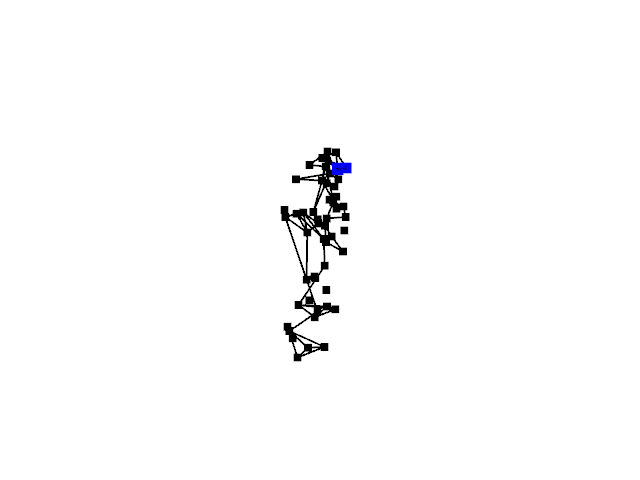

In [612]:
rec = model.decode(text_encoded).squeeze(0)
visualize(rec,filename='reconstructed')
Image(filename='animate/reconstructed.gif')

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 74.23it/s]


Saved animate/reconstructed2.gif and animate/reconstructed2.mp4


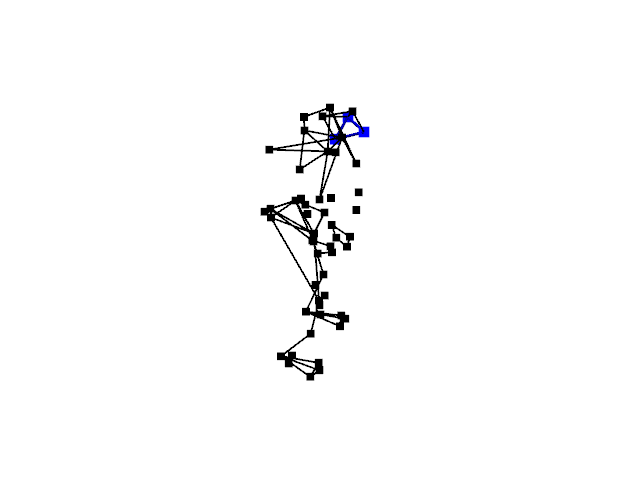

In [450]:
rec = model.decode(encoded).squeeze(0)
visualize(rec,filename='reconstructed2')
Image(filename='animate/reconstructed2.gif')

In [626]:
# dance to text 
# idea = to use knn

In [670]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=2, weights='distance',algorithm='kd_tree')
knn.fit(text_latent.detach(), manual_labels)

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=2, weights='distance')

In [674]:
text_encoded = text_mapper(get_bert_embedding('neck rotate'))
predicted_labels = knn.predict(encoded.detach())
predicted_labels

array(['neck rotation'], dtype='<U36')